# Optimización de rutas de última milla
[Author: Elias Buitrago Bolivar](https://github.com/ebuitrago?tab=repositories)

Electiva Técnica II - Ciencia de Datos\
Tecnología en Desarrollo de Software

Este notebook está diseñado para trabajar un problema de optimización aplicado a logística urbana. La idea no es resolver un problema de optimización de forma abstracta, sino revisar un caso más cercano a una situación real. En ese sentido, se propone el estudio de caso de una empresa que debe entregar pedidos, controlar la capacidad de carga de los vehículos y justificar por qué algunos algoritmos no escalan cuando aumenta el número de clientes. El taller integra carga de datos, validación básica, cálculo de distancias geográficas, análisis de complejidad, fuerza bruta acotada y construcción de rutas mediante una heurística sencilla.

## Relación con las semanas 14, 15 y 16

Semana 14: búsqueda, descarga, preparación y modelado inicial de datos desde Kaggle.  
Semana 15: análisis de complejidad, fuerza bruta acotada y discusión del crecimiento combinatorio.  
Semana 16: aplicación de heurísticas para construir rutas y mejorar una solución inicial.

En este notebook se usará como referencia el dataset Brazilian E-Commerce Public Dataset by Olist, disponible en Kaggle. Sin embargo, cada grupo puede usar otro dataset de e-commerce, entregas, logística o movilidad, siempre que logre construir al menos 30 ubicaciones reales de entrega con latitud y longitud.

## Objetivos de la actividad

1. Buscar y preparar un dataset de Kaggle relacionado con comercio electrónico, entregas o logística.
2. Construir un subconjunto mínimo de 30 ubicaciones reales de entrega.
3. Calcular una matriz de distancias usando la fórmula de Haversine.
4. Analizar por qué la fuerza bruta no escala cuando aumenta el número de pedidos.
5. Construir rutas de entrega respetando una capacidad máxima de carga por vehículo.
6. Comparar una solución inicial con una mejora local usando 2-opt.
7. Presentar resultados mediante tablas, gráficos y mapas.

## Contexto del caso

LogiExpress es una empresa de distribución urbana de mercancías. Para este ejercicio se asume que la empresa tiene un centro de distribución principal y varios pedidos pendientes en una misma ciudad.

Cada pedido debe tener una ubicación geográfica y un peso estimado. La empresa debe organizar rutas de entrega sin superar la capacidad máxima de carga de cada vehículo. En el desarrollo se trabajará con una capacidad de referencia de 100 kg por vehículo.

Desde el punto de vista algorítmico, este problema se aproxima al problema de rutas de vehículos con capacidad limitada. En un escenario real podrían incluirse ventanas de tiempo, tráfico, prioridad del cliente, disponibilidad de vehículos y costos operativos. En este taller se mantendrá una versión simplificada para poder comprender el comportamiento de los algoritmos.

## Instalación y carga de librerías

En Google Colab normalmente `pandas`, `numpy`, `matplotlib` y `folium` se encuentran disponibles. Si alguna librería no carga, se puede instalar desde una celda independiente usando `pip`.

In [4]:
# En Google Colab se pueden activar estas instalaciones si el entorno no las tiene.
!pip install -q folium
!pip install -q kagglehub

In [1]:
import itertools
import math
import os
import shutil
import subprocess
import time
import unicodedata
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Parámetros generales del problema

La capacidad del vehículo se deja como variable para facilitar la experimentación. También se define una semilla para que los resultados sean reproducibles.

In [5]:
capacidad_vehiculo_kg = 100
semilla = 42

# Para la primera ejecución en clase se dejan pocos registros.
# Para la entrega final, cambien esta variable a 30.
numero_pedidos_a_cargar = 8
minimo_pedidos_entrega_final = 30

# Se conserva esta variable porque varias funciones posteriores la utilizan.
n_pedidos_requeridos = numero_pedidos_a_cargar

# En Olist suele existir una buena cantidad de pedidos para São Paulo.
# Si el grupo usa otro dataset, debe ajustar este criterio.
ciudad_objetivo = "sao paulo"

# Recomendado para Colab. Si falla por conexión o permisos, el notebook buscará archivos locales.
usar_descarga_kagglehub = True
permitir_dataset_demo = True

np.random.seed(semilla)

print("Capacidad máxima por vehículo:", capacidad_vehiculo_kg, "kg")
print("Pedidos cargados en esta ejecución:", numero_pedidos_a_cargar)
print("Mínimo requerido para la entrega final:", minimo_pedidos_entrega_final)

if numero_pedidos_a_cargar < minimo_pedidos_entrega_final:
    print("Modo de prueba: el notebook corre con pocos registros.")
    print("Para la entrega final se debe usar numero_pedidos_a_cargar = 30.")

Capacidad máxima por vehículo: 100 kg
Pedidos cargados en esta ejecución: 8
Mínimo requerido para la entrega final: 30
Modo de prueba: el notebook corre con pocos registros.
Para la entrega final se debe usar numero_pedidos_a_cargar = 30.


## Semana 14: búsqueda, carga y preparación de datos desde Kaggle

En esta primera fase se trabaja el componente propio de la semana 14: *modelado de algoritmos y datos con Kaggle*. Para evitar errores de configuración, en este notebook se deja configurado un cargue inicial completo usando el dataset [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Entonces, la lógica de trabajo será la siguiente:

1. Verificar la correcta ejecución del notebook con pocos registros.
2. Cambiar la variable `numero_pedidos_a_cargar` al valor solicitado en la actividad autónoma del estudiante.
3. Documentar el dataset utilizado, revisar las tablas originales y construir la tabla mínima para el problema de rutas.

La tabla final que necesita el problema de optimización debe contener, como mínimo:

| Columna | Descripción |
|---|---|
| `Pedido_ID` | Identificador del pedido. |
| `Latitud` | Coordenada geográfica del cliente. |
| `Longitud` | Coordenada geográfica del cliente. |
| `Peso_kg` | Peso aproximado del pedido en kilogramos. |

Aunque el dataset original contiene muchas más variables, para este ejercicio se usan únicamente las necesarias para construir un caso de ruteo de última milla con restricción de capacidad.

## Cargue inicial completo del dataset Kaggle

Esta celda concentra el cargue de datos para reducir errores. Primero intenta descargar el dataset con `kagglehub`. Si no es posible, busca los archivos `.csv` en rutas comunes de Colab o Google Drive. Si tampoco los encuentra, activa un dataset de demostración para que el resto del notebook pueda ejecutarse en clase.

La entrega final debe realizarse con datos de Kaggle, no con el dataset de demostración.

In [6]:
archivos_olist = {
    "ordenes": "olist_orders_dataset.csv",
    "clientes": "olist_customers_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "productos": "olist_products_dataset.csv",
    "geolocalizacion": "olist_geolocation_dataset.csv"
}

rutas_busqueda = [
    Path("/content/datos_olist"),
    Path("/content"),
    Path("/content/drive/MyDrive/data/olist"),
    Path("/content/drive/MyDrive/datos/olist"),
    Path("/mnt/data/datos_olist")
]


def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([caracter for caracter in texto if not unicodedata.combining(caracter)])
    return texto


def obtener_moda(serie):
    serie = serie.dropna()
    if len(serie) == 0:
        return np.nan
    return serie.mode().iloc[0]


def buscar_archivos_olist(ruta_base, archivos):
    ruta_base = Path(ruta_base)
    if not ruta_base.exists():
        return None

    carpetas_candidatas = [ruta_base]
    carpetas_candidatas.extend([ruta for ruta in ruta_base.rglob("*") if ruta.is_dir()])

    for carpeta in carpetas_candidatas:
        encontrados = [(carpeta / archivo).exists() for archivo in archivos.values()]
        if all(encontrados):
            return carpeta

    return None


def construir_pedidos_olist(ruta_olist, archivos):
    ordenes = pd.read_csv(ruta_olist / archivos["ordenes"])
    clientes = pd.read_csv(ruta_olist / archivos["clientes"])
    items = pd.read_csv(ruta_olist / archivos["items"])
    productos = pd.read_csv(ruta_olist / archivos["productos"])
    geolocalizacion = pd.read_csv(ruta_olist / archivos["geolocalizacion"])

    geolocalizacion_limpia = geolocalizacion.copy()
    geolocalizacion_limpia["geolocation_lat"] = pd.to_numeric(
        geolocalizacion_limpia["geolocation_lat"], errors="coerce"
    )
    geolocalizacion_limpia["geolocation_lng"] = pd.to_numeric(
        geolocalizacion_limpia["geolocation_lng"], errors="coerce"
    )

    geolocalizacion_limpia = geolocalizacion_limpia.dropna(
        subset=["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]
    )

    geo_resumen = (
        geolocalizacion_limpia
        .groupby("geolocation_zip_code_prefix")
        .agg(
            Latitud=("geolocation_lat", "median"),
            Longitud=("geolocation_lng", "median"),
            Ciudad=("geolocation_city", obtener_moda),
            Estado=("geolocation_state", obtener_moda)
        )
        .reset_index()
        .rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix"})
    )

    productos_peso = productos[["product_id", "product_weight_g"]].copy()
    productos_peso["product_weight_g"] = pd.to_numeric(productos_peso["product_weight_g"], errors="coerce")

    items_productos = items.merge(productos_peso, on="product_id", how="left")
    peso_mediano = items_productos["product_weight_g"].median()
    items_productos["product_weight_g"] = items_productos["product_weight_g"].fillna(peso_mediano)

    peso_por_pedido = (
        items_productos
        .groupby("order_id")
        .agg(
            Peso_kg=("product_weight_g", lambda valores: valores.sum() / 1000),
            Cantidad_items=("order_item_id", "count")
        )
        .reset_index()
    )

    pedidos_olist = (
        ordenes
        .merge(clientes, on="customer_id", how="inner")
        .merge(peso_por_pedido, on="order_id", how="inner")
        .merge(geo_resumen, on="customer_zip_code_prefix", how="inner")
    )

    pedidos_olist = pedidos_olist[pedidos_olist["order_status"] == "delivered"].copy()
    pedidos_olist["Ciudad_normalizada"] = pedidos_olist["Ciudad"].apply(limpiar_texto)

    pedidos_olist = pedidos_olist.dropna(subset=["Latitud", "Longitud", "Peso_kg"])
    pedidos_olist = pedidos_olist[
        (pedidos_olist["Latitud"].between(-35, 6)) &
        (pedidos_olist["Longitud"].between(-75, -30)) &
        (pedidos_olist["Peso_kg"] > 0) &
        (pedidos_olist["Peso_kg"] <= capacidad_vehiculo_kg)
    ].copy()

    tablas_originales = {
        "ordenes": ordenes,
        "clientes": clientes,
        "items": items,
        "productos": productos,
        "geolocalizacion": geolocalizacion
    }

    return pedidos_olist, tablas_originales


def crear_dataset_demo(numero_pedidos, deposito_demo=None):
    if deposito_demo is None:
        deposito_demo = [4.6482, -74.0721]

    latitudes = deposito_demo[0] + np.random.normal(0, 0.025, numero_pedidos)
    longitudes = deposito_demo[1] + np.random.normal(0, 0.030, numero_pedidos)
    pesos = np.random.randint(5, 36, numero_pedidos)

    pedidos_demo = pd.DataFrame({
        "Pedido_ID": [f"P-{i:03d}" for i in range(1, numero_pedidos + 1)],
        "Latitud": latitudes,
        "Longitud": longitudes,
        "Peso_kg": pesos,
        "Ciudad": "Bogotá demo",
        "Estado": "Demo",
        "Cantidad_items": 1
    })

    return pedidos_demo, deposito_demo


ruta_olist = None
usando_dataset_demo = False
pedidos_olist = pd.DataFrame()
tablas_originales = {}
mensaje_carga = ""

if usar_descarga_kagglehub:
    try:
        try:
            import kagglehub
        except ModuleNotFoundError:
            subprocess.run(["pip", "install", "-q", "kagglehub"], check=False)
            import kagglehub

        ruta_descargada = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
        ruta_olist = buscar_archivos_olist(ruta_descargada, archivos_olist)
        mensaje_carga = f"Descarga con kagglehub revisada en: {ruta_descargada}"
    except Exception as error:
        mensaje_carga = f"No fue posible descargar con kagglehub: {error}"

if ruta_olist is None:
    for ruta in rutas_busqueda:
        ruta_encontrada = buscar_archivos_olist(ruta, archivos_olist)
        if ruta_encontrada is not None:
            ruta_olist = ruta_encontrada
            mensaje_carga = f"Archivos encontrados localmente en: {ruta_olist}"
            break

if ruta_olist is not None:
    pedidos_olist, tablas_originales = construir_pedidos_olist(ruta_olist, archivos_olist)

    pedidos_ciudad = pedidos_olist[pedidos_olist["Ciudad_normalizada"] == ciudad_objetivo].copy()

    if len(pedidos_ciudad) < numero_pedidos_a_cargar:
        print("La ciudad seleccionada no tiene suficientes pedidos para el número solicitado.")
        print("Se usará una muestra general del dataset limpio.")
        pedidos_ciudad = pedidos_olist.copy()

    pedidos = (
        pedidos_ciudad
        .sample(n=numero_pedidos_a_cargar, random_state=semilla)
        .reset_index(drop=True)
    )

    pedidos = pedidos[["order_id", "Latitud", "Longitud", "Peso_kg", "Ciudad", "Estado", "Cantidad_items"]].copy()
    pedidos = pedidos.rename(columns={"order_id": "Pedido_ID"})
    pedidos["Peso_kg"] = pedidos["Peso_kg"].round(2)

    deposito = [pedidos["Latitud"].median(), pedidos["Longitud"].median()]

else:
    if not permitir_dataset_demo:
        raise FileNotFoundError("No se encontraron los archivos de Olist y el dataset demo está desactivado.")

    usando_dataset_demo = True
    pedidos, deposito = crear_dataset_demo(numero_pedidos_a_cargar)
    mensaje_carga = "Se activó dataset de demostración. La entrega final debe usar Kaggle."

print(mensaje_carga)
print("Usando dataset demo:", usando_dataset_demo)
print("Pedidos cargados:", len(pedidos))
print("Depósito definido:", deposito)

pedidos.head(numero_pedidos_a_cargar)

100%|██████████| 42.6M/42.6M [00:00<00:00, 126MB/s]

Extracting files...


Descarga con kagglehub revisada en: /root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
Usando dataset demo: False
Pedidos cargados: 8
Depósito definido: [-23.558485238095056, -46.68078190070834]


,Pedido_ID,Latitud,Longitud,Peso_kg,Ciudad,Estado,Cantidad_items
0,a55945f45b2bf0c2b8b3ffae52d10213,-23.500935,-46.664106,0.35,sao paulo,SP,1
1,8d36b9d7a238d9d50b8be72fe69ff6eb,-23.611509,-46.737061,1.75,sao paulo,SP,1
2,6b8c07c310d8c6a39e79ed3d38e6578f,-23.749818,-46.701408,15.35,sao paulo,SP,1
3,f0e0be414a28021f1a90bfaae3b26c61,-23.472852,-46.647491,0.35,sao paulo,SP,1
4,531abf2d5cc78f7a49d9ba560cbbfe7a,-23.523174,-46.705666,0.18,sao paulo,SP,1
5,3027797ce35841bf74917c0b0ea1a38d,-23.570889,-46.635523,1.20,sao paulo,SP,1
6,111fd867f837d390ba296535e5ce8b92,-23.546081,-46.643810,1.30,sao paulo,SP,1
7,611793bc968aac5d1a9c623d1ab8aea6,-23.711269,-46.697457,2.60,sao paulo,SP,1


## Evidencia de carga y preparación del dataset

Esta evidencia debe quedar en el notebook final. Si el grupo cambia de dataset, debe conservar una tabla similar para explicar el origen de los datos, el criterio de selección y el número de pedidos usados.

In [7]:
nombre_dataset = "Brazilian E-Commerce Public Dataset by Olist"
fuente_dataset = "Kaggle"
enlace_dataset = "https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce"
criterio_seleccion = "Dataset de comercio electrónico con pedidos, clientes, productos y geolocalización aproximada por prefijo postal."

if usando_dataset_demo:
    registros_originales = len(pedidos)
    registros_limpios = len(pedidos)
    criterio_muestra = "Dataset de demostración. Debe reemplazarse por datos reales de Kaggle."
else:
    registros_originales = len(tablas_originales["ordenes"])
    registros_limpios = len(pedidos_olist)
    criterio_muestra = f"Muestra de {numero_pedidos_a_cargar} pedidos entregados asociados a {ciudad_objetivo}."

ficha_dataset = pd.DataFrame({
    "Campo": [
        "Nombre",
        "Fuente",
        "Enlace",
        "Criterio de selección",
        "Registros originales o base inicial",
        "Registros disponibles después de limpieza",
        "Pedidos cargados en esta ejecución",
        "Mínimo requerido para entrega final",
        "Uso de datos de demostración"
    ],
    "Descripción": [
        nombre_dataset,
        fuente_dataset,
        enlace_dataset,
        criterio_seleccion,
        registros_originales,
        registros_limpios,
        len(pedidos),
        minimo_pedidos_entrega_final,
        usando_dataset_demo
    ]
})

ficha_dataset

,Campo,Descripción
0,Nombre,Brazilian E-Commerce Public Dataset by Olist
1,Fuente,Kaggle
2,Enlace,https://www.kaggle.com/datasets/olistbr/brazil...
3,Criterio de selección,"Dataset de comercio electrónico con pedidos, c..."
4,Registros originales o base inicial,99441
5,Registros disponibles después de limpieza,96198
6,Pedidos cargados en esta ejecución,8
7,Mínimo requerido para entrega final,30
8,Uso de datos de demostración,False


## Revisión de tablas originales

Cuando el dataset de Kaggle está disponible, esta celda permite revisar el tamaño de las tablas originales y una muestra de registros. Esta revisión es útil para que el grupo pueda explicar por qué se necesitó unir varias tablas antes de resolver el problema de rutas.

In [8]:
if not usando_dataset_demo:
    resumen_tablas = pd.DataFrame({
        "Tabla": list(tablas_originales.keys()),
        "Filas": [len(tabla) for tabla in tablas_originales.values()],
        "Columnas": [tabla.shape[1] for tabla in tablas_originales.values()]
    })

    display(resumen_tablas)
    display(tablas_originales["ordenes"].head(3))
    display(tablas_originales["clientes"].head(3))
    display(tablas_originales["items"].head(3))
    display(tablas_originales["productos"].head(3))
    display(tablas_originales["geolocalizacion"].head(3))
else:
    print("Revisión omitida porque se está usando el dataset de demostración.")
    print("Para la entrega final, esta celda debe mostrar las tablas originales de Kaggle.")

,Tabla,Filas,Columnas
0,ordenes,99441,8
1,clientes,99441,5
2,items,112650,7
3,productos,32951,9
4,geolocalizacion,1000163,5


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


## Dataset mínimo para el problema de rutas

A partir de las tablas originales se construye una tabla más pequeña y útil para el problema de optimización. En esta versión de prueba se cargan pocos pedidos; para la entrega final se debe cambiar `numero_pedidos_a_cargar = 30` en la sección de parámetros generales.

In [9]:
columnas_mostrar = ["Pedido_ID", "Latitud", "Longitud", "Peso_kg", "Ciudad", "Estado", "Cantidad_items"]

print("Número de pedidos disponibles para el ruteo:", len(pedidos))
print("Peso total pendiente:", round(pedidos["Peso_kg"].sum(), 2), "kg")

if len(pedidos) < minimo_pedidos_entrega_final:
    print("Aún no se cumple el mínimo de la entrega final.")
    print("Cambie numero_pedidos_a_cargar a 30 cuando valide que el cargue funciona.")

pedidos[columnas_mostrar].head(numero_pedidos_a_cargar)

Número de pedidos disponibles para el ruteo: 8
Peso total pendiente: 23.08 kg
Aún no se cumple el mínimo de la entrega final.
Cambie numero_pedidos_a_cargar a 30 cuando valide que el cargue funciona.


,Pedido_ID,Latitud,Longitud,Peso_kg,Ciudad,Estado,Cantidad_items
0,a55945f45b2bf0c2b8b3ffae52d10213,-23.500935,-46.664106,0.35,sao paulo,SP,1
1,8d36b9d7a238d9d50b8be72fe69ff6eb,-23.611509,-46.737061,1.75,sao paulo,SP,1
2,6b8c07c310d8c6a39e79ed3d38e6578f,-23.749818,-46.701408,15.35,sao paulo,SP,1
3,f0e0be414a28021f1a90bfaae3b26c61,-23.472852,-46.647491,0.35,sao paulo,SP,1
4,531abf2d5cc78f7a49d9ba560cbbfe7a,-23.523174,-46.705666,0.18,sao paulo,SP,1
5,3027797ce35841bf74917c0b0ea1a38d,-23.570889,-46.635523,1.20,sao paulo,SP,1
6,111fd867f837d390ba296535e5ce8b92,-23.546081,-46.643810,1.30,sao paulo,SP,1
7,611793bc968aac5d1a9c623d1ab8aea6,-23.711269,-46.697457,2.60,sao paulo,SP,1


## Diccionario mínimo de variables

Esta tabla resume las variables que se usarán en el resto del notebook. La idea no es conservar todas las columnas del dataset original, sino las necesarias para modelar el problema de entrega.

In [10]:
diccionario_variables = pd.DataFrame({
    "Variable": ["Pedido_ID", "Latitud", "Longitud", "Peso_kg", "Ciudad", "Estado", "Cantidad_items"],
    "Uso en el problema": [
        "Identifica cada entrega.",
        "Permite ubicar el cliente y calcular distancia.",
        "Permite ubicar el cliente y calcular distancia.",
        "Define la restricción de capacidad del vehículo.",
        "Permite filtrar o justificar la zona de trabajo.",
        "Permite identificar la región de los pedidos.",
        "Permite tener una idea básica del tamaño del pedido."
    ]
})

diccionario_variables

,Variable,Uso en el problema
0,Pedido_ID,Identifica cada entrega.
1,Latitud,Permite ubicar el cliente y calcular distancia.
2,Longitud,Permite ubicar el cliente y calcular distancia.
3,Peso_kg,Define la restricción de capacidad del vehículo.
4,Ciudad,Permite filtrar o justificar la zona de trabajo.
5,Estado,Permite identificar la región de los pedidos.
6,Cantidad_items,Permite tener una idea básica del tamaño del p...


## Revisión básica del dataset final

Antes de calcular distancias o aplicar algoritmos, se revisa que el conjunto de datos tenga las columnas necesarias y que no existan valores nulos en coordenadas o pesos. Esta validación debe ejecutarse tanto con pocos registros de prueba como con los 30 pedidos de la entrega final.

In [11]:
columnas_requeridas = ["Pedido_ID", "Latitud", "Longitud", "Peso_kg"]

for columna in columnas_requeridas:
    if columna not in pedidos.columns:
        raise ValueError(f"Falta la columna requerida: {columna}")

pedidos = pedidos.copy()
pedidos["Latitud"] = pd.to_numeric(pedidos["Latitud"], errors="coerce")
pedidos["Longitud"] = pd.to_numeric(pedidos["Longitud"], errors="coerce")
pedidos["Peso_kg"] = pd.to_numeric(pedidos["Peso_kg"], errors="coerce")

pedidos = pedidos.dropna(subset=["Latitud", "Longitud", "Peso_kg"])
pedidos = pedidos[pedidos["Peso_kg"] > 0].copy()
pedidos = pedidos.drop_duplicates(subset=["Pedido_ID", "Latitud", "Longitud"])
pedidos = pedidos.reset_index(drop=True)
pedidos["Nodo"] = np.arange(1, len(pedidos) + 1)

print("Cantidad de pedidos disponibles:", len(pedidos))
print("Peso total pendiente:", round(pedidos["Peso_kg"].sum(), 2), "kg")
pedidos.head()

Cantidad de pedidos disponibles: 8
Peso total pendiente: 23.08 kg


,Pedido_ID,Latitud,Longitud,Peso_kg,Ciudad,Estado,Cantidad_items,Nodo
0,a55945f45b2bf0c2b8b3ffae52d10213,-23.500935,-46.664106,0.35,sao paulo,SP,1,1
1,8d36b9d7a238d9d50b8be72fe69ff6eb,-23.611509,-46.737061,1.75,sao paulo,SP,1,2
2,6b8c07c310d8c6a39e79ed3d38e6578f,-23.749818,-46.701408,15.35,sao paulo,SP,1,3
3,f0e0be414a28021f1a90bfaae3b26c61,-23.472852,-46.647491,0.35,sao paulo,SP,1,4
4,531abf2d5cc78f7a49d9ba560cbbfe7a,-23.523174,-46.705666,0.18,sao paulo,SP,1,5


## Exportación del subconjunto limpio

Esta celda permite guardar el archivo limpio que se usará en el resto del notebook. En la entrega final, este archivo debe quedar en el repositorio junto con el notebook.

In [12]:
pedidos.to_csv("pedidos_logiexpress_limpio.csv", index=False)
print("Archivo generado: pedidos_logiexpress_limpio.csv")

Archivo generado: pedidos_logiexpress_limpio.csv


## Visualización inicial de pedidos

El mapa permite revisar si las coordenadas cargadas son razonables. En una práctica real, este paso evita errores frecuentes como latitudes y longitudes invertidas, coordenadas fuera de la ciudad o registros duplicados.

In [13]:
mapa_pedidos = folium.Map(location=deposito, zoom_start=11)

folium.Marker(
    location=deposito,
    popup="Depósito LogiExpress",
    icon=folium.Icon(color="red", icon="home")
).add_to(mapa_pedidos)

for _, pedido in pedidos.iterrows():
    texto_popup = f"{pedido['Pedido_ID']} | Peso: {pedido['Peso_kg']} kg"
    folium.CircleMarker(
        location=[pedido["Latitud"], pedido["Longitud"]],
        radius=5,
        popup=texto_popup,
        color="blue",
        fill=True,
        fill_opacity=0.7
    ).add_to(mapa_pedidos)

mapa_pedidos

## Cálculo de distancias con Haversine

La fórmula de Haversine permite calcular la distancia aproximada entre dos puntos geográficos usando latitud y longitud. Esta distancia no reemplaza un cálculo de rutas sobre calles, pero es suficiente para estudiar el comportamiento del algoritmo y construir una primera aproximación del problema.

In [14]:
def haversine_km(latitud_1, longitud_1, latitud_2, longitud_2):
    radio_tierra_km = 6371

    latitud_1 = math.radians(latitud_1)
    longitud_1 = math.radians(longitud_1)
    latitud_2 = math.radians(latitud_2)
    longitud_2 = math.radians(longitud_2)

    diferencia_latitud = latitud_2 - latitud_1
    diferencia_longitud = longitud_2 - longitud_1

    a = math.sin(diferencia_latitud / 2) ** 2 + math.cos(latitud_1) * math.cos(latitud_2) * math.sin(diferencia_longitud / 2) ** 2
    c = 2 * math.asin(math.sqrt(a))

    return radio_tierra_km * c

In [15]:
def construir_matriz_distancias(pedidos, deposito):
    puntos = pd.DataFrame({
        "Nodo": [0],
        "Pedido_ID": ["Deposito"],
        "Latitud": [deposito[0]],
        "Longitud": [deposito[1]],
        "Peso_kg": [0]
    })

    puntos = pd.concat(
        [puntos, pedidos[["Nodo", "Pedido_ID", "Latitud", "Longitud", "Peso_kg"]]],
        ignore_index=True
    )

    n_puntos = len(puntos)
    matriz = np.zeros((n_puntos, n_puntos))

    for i in range(n_puntos):
        for j in range(n_puntos):
            matriz[i, j] = haversine_km(
                puntos.loc[i, "Latitud"],
                puntos.loc[i, "Longitud"],
                puntos.loc[j, "Latitud"],
                puntos.loc[j, "Longitud"]
            )

    matriz_distancias = pd.DataFrame(matriz, index=puntos["Nodo"], columns=puntos["Nodo"])

    return puntos, matriz_distancias

puntos, matriz_distancias = construir_matriz_distancias(pedidos, deposito)
matriz_distancias.head()

Nodo,0,1,2,3,4,5,6,7,8
Nodo,,,,,,,,,
0,0.000000,6.621267,8.225258,21.378711,10.108847,4.674620,4.814704,4.013070,17.073540
1,6.621267,0.000000,14.369074,27.934218,3.552757,4.906294,8.306455,5.429782,23.633695
2,8.225258,14.369074,0.000000,15.801983,17.918757,10.330496,11.289756,11.968363,11.803378
3,21.378711,27.934218,15.801983,0.000000,31.283271,25.205448,20.997064,23.401830,4.305236
4,10.108847,3.552757,17.918757,31.283271,0.000000,8.154852,10.969299,8.151314,26.995280


In [16]:
matriz_distancias.to_csv("matriz_distancias_haversine.csv")
print("Dimensión de la matriz:", matriz_distancias.shape)
print("Archivo generado: matriz_distancias_haversine.csv")

Dimensión de la matriz: (9, 9)
Archivo generado: matriz_distancias_haversine.csv


## Función para calcular la distancia de una ruta

Toda ruta inicia en el depósito, visita un conjunto de pedidos y regresa nuevamente al depósito. En la matriz de distancias el depósito corresponde al nodo 0.

In [17]:
def calcular_distancia_ruta(ruta, matriz_distancias):
    distancia_total = 0

    for i in range(len(ruta) - 1):
        nodo_actual = ruta[i]
        nodo_siguiente = ruta[i + 1]
        distancia_total += matriz_distancias.loc[nodo_actual, nodo_siguiente]

    return distancia_total

## Semana 15: fuerza bruta acotada y análisis de complejidad

La fuerza bruta permite encontrar la mejor solución cuando el número de pedidos es muy pequeño. Sin embargo, su costo crece de forma acelerada. Por eso en este notebook se limita su uso a subconjuntos pequeños.

Para la selección de pedidos con capacidad se usa una búsqueda de combinaciones. Para la ruta exacta se prueban permutaciones. No se debe ejecutar la ruta exacta con 30 pedidos completos, porque el número de permutaciones crece factorialmente y satura rápidamente el entorno de ejecución.

In [18]:
def seleccionar_pedidos_por_fuerza_bruta(pedidos, capacidad_vehiculo_kg, max_pedidos=12):
    pedidos_prueba = pedidos.head(max_pedidos).copy()
    nodos = pedidos_prueba["Nodo"].astype(int).tolist()
    pesos = dict(zip(pedidos_prueba["Nodo"].astype(int), pedidos_prueba["Peso_kg"]))

    mejor_combinacion = []
    mejor_peso = 0

    for r in range(1, len(nodos) + 1):
        for combinacion in itertools.combinations(nodos, r):
            peso_combinacion = sum(pesos[nodo] for nodo in combinacion)

            if peso_combinacion <= capacidad_vehiculo_kg and peso_combinacion > mejor_peso:
                mejor_combinacion = list(combinacion)
                mejor_peso = peso_combinacion

    return mejor_combinacion, mejor_peso

mejor_combinacion, mejor_peso = seleccionar_pedidos_por_fuerza_bruta(
    pedidos,
    capacidad_vehiculo_kg,
    max_pedidos=12
)

print("Mejor combinación encontrada:", mejor_combinacion)
print("Peso total:", round(mejor_peso, 2), "kg")

Mejor combinación encontrada: [1, 2, 3, 4, 5, 6, 7, 8]
Peso total: 23.08 kg


In [19]:
def encontrar_mejor_ruta_exacta(nodos, matriz_distancias):
    mejor_ruta = None
    mejor_distancia = float("inf")

    for permutacion in itertools.permutations(nodos):
        ruta = [0] + list(permutacion) + [0]
        distancia = calcular_distancia_ruta(ruta, matriz_distancias)

        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_ruta = ruta

    return mejor_ruta, mejor_distancia

nodos_prueba = pedidos["Nodo"].head(7).astype(int).tolist()

inicio = time.time()
mejor_ruta_exacta, mejor_distancia_exacta = encontrar_mejor_ruta_exacta(nodos_prueba, matriz_distancias)
fin = time.time()

print("Mejor ruta exacta:", mejor_ruta_exacta)
print("Distancia:", round(mejor_distancia_exacta, 2), "km")
print("Tiempo de ejecución:", round(fin - inicio, 4), "segundos")

Mejor ruta exacta: [0, 2, 3, 6, 7, 4, 1, 5, 0]
Distancia: 69.19 km
Tiempo de ejecución: 0.3715 segundos


## Experimento de crecimiento del tiempo de ejecución

El siguiente experimento se ejecuta con pocos pedidos. La intención es observar el crecimiento del tiempo de ejecución y relacionarlo con el número de permutaciones posibles.

In [20]:
resultados_tiempo = []

for n in range(3, 9):
    nodos = pedidos["Nodo"].head(n).astype(int).tolist()

    inicio = time.time()
    _, distancia_prueba = encontrar_mejor_ruta_exacta(nodos, matriz_distancias)
    fin = time.time()

    resultados_tiempo.append({
        "n_pedidos": n,
        "permutaciones": math.factorial(n),
        "tiempo_segundos": fin - inicio,
        "distancia_km": distancia_prueba
    })

resultados_tiempo = pd.DataFrame(resultados_tiempo)
resultados_tiempo

,n_pedidos,permutaciones,tiempo_segundos,distancia_km
0,3,6,0.000512,58.171035
1,4,24,0.002474,65.211371
2,5,120,0.009326,65.840066
3,6,720,0.056498,69.127275
4,7,5040,0.357523,69.194273
5,8,40320,2.977590,69.338703


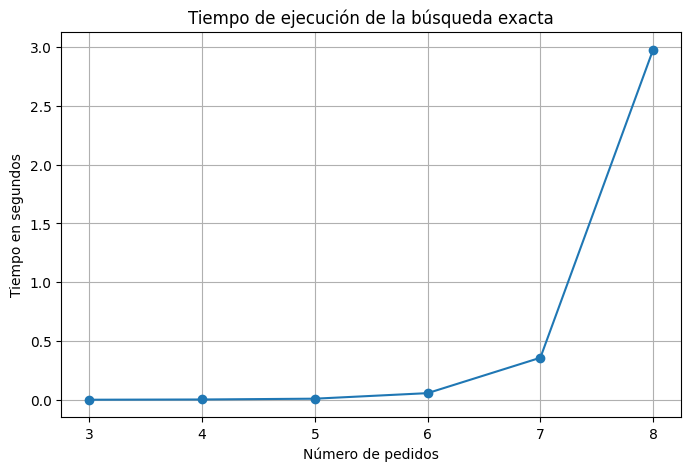

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_tiempo["n_pedidos"], resultados_tiempo["tiempo_segundos"], marker="o")
plt.title("Tiempo de ejecución de la búsqueda exacta")
plt.xlabel("Número de pedidos")
plt.ylabel("Tiempo en segundos")
plt.grid()
plt.show()

## Interpretación del experimento de complejidad

En esta celda el grupo debe explicar, con sus propias palabras, por qué el tiempo de ejecución crece tan rápido cuando aumenta el número de pedidos. La explicación debe relacionar el experimento con la notación Big-O y con el comportamiento factorial del TSP exacto.

In [22]:
interpretacion_complejidad = '''
Escriba aquí la interpretación del grupo. Deben explicar por qué la solución exacta por permutaciones no es viable para 30 pedidos o más.
'''

print(interpretacion_complejidad)


Escriba aquí la interpretación del grupo. Deben explicar por qué la solución exacta por permutaciones no es viable para 30 pedidos o más.



## Semana 16: construcción de rutas por capacidad

Para trabajar con más pedidos se usa una heurística. Primero se ordenan los pedidos por su ángulo respecto al depósito, lo cual genera una aproximación tipo barrido geográfico. Luego se arman grupos sin superar la capacidad máxima del vehículo.

Esta no es una solución óptima global, pero permite resolver el caso de forma rápida y deja abierta la discusión sobre calidad de la solución, escalabilidad y trade-offs.

In [23]:
def calcular_angulo_respecto_deposito(latitud, longitud, deposito):
    return math.atan2(latitud - deposito[0], longitud - deposito[1])

pedidos_ruteo = pedidos.copy()
pedidos_ruteo["Angulo"] = pedidos_ruteo.apply(
    lambda fila: calcular_angulo_respecto_deposito(fila["Latitud"], fila["Longitud"], deposito),
    axis=1
)

pedidos_ruteo["Distancia_deposito_km"] = pedidos_ruteo.apply(
    lambda fila: haversine_km(deposito[0], deposito[1], fila["Latitud"], fila["Longitud"]),
    axis=1
)

pedidos_ruteo = pedidos_ruteo.sort_values(["Angulo", "Distancia_deposito_km"]).reset_index(drop=True)
pedidos_ruteo.head()

,Pedido_ID,Latitud,Longitud,Peso_kg,Ciudad,Estado,Cantidad_items,Nodo,Angulo,Distancia_deposito_km
0,8d36b9d7a238d9d50b8be72fe69ff6eb,-23.611509,-46.737061,1.75,sao paulo,SP,1,2,-2.385963,8.225258
1,611793bc968aac5d1a9c623d1ab8aea6,-23.711269,-46.697457,2.60,sao paulo,SP,1,8,-1.679510,17.073540
2,6b8c07c310d8c6a39e79ed3d38e6578f,-23.749818,-46.701408,15.35,sao paulo,SP,1,3,-1.678181,21.378711
3,3027797ce35841bf74917c0b0ea1a38d,-23.570889,-46.635523,1.20,sao paulo,SP,1,6,-0.267500,4.814704
4,111fd867f837d390ba296535e5ce8b92,-23.546081,-46.643810,1.30,sao paulo,SP,1,7,0.323702,4.013070


In [24]:
def agrupar_pedidos_por_capacidad(pedidos_ordenados, capacidad_vehiculo_kg):
    rutas = []
    ruta_actual = []
    peso_actual = 0

    for _, pedido in pedidos_ordenados.iterrows():
        peso_pedido = pedido["Peso_kg"]

        if peso_actual + peso_pedido <= capacidad_vehiculo_kg:
            ruta_actual.append(int(pedido["Nodo"]))
            peso_actual += peso_pedido
        else:
            rutas.append({
                "nodos": ruta_actual,
                "peso_total_kg": peso_actual
            })

            ruta_actual = [int(pedido["Nodo"])]
            peso_actual = peso_pedido

    if len(ruta_actual) > 0:
        rutas.append({
            "nodos": ruta_actual,
            "peso_total_kg": peso_actual
        })

    return rutas

rutas_base = agrupar_pedidos_por_capacidad(pedidos_ruteo, capacidad_vehiculo_kg)
rutas_base

[{'nodos': [2, 8, 3, 6, 7, 4, 1, 5], 'peso_total_kg': 23.080000000000002}]

## Ordenamiento interno de cada ruta con vecino más cercano

Después de crear los grupos, se ordenan los pedidos dentro de cada ruta usando la regla de vecino más cercano. Esta regla escoge siempre el pedido no visitado más cercano al punto actual.

In [25]:
def ordenar_por_vecino_mas_cercano(nodos, matriz_distancias):
    nodos_pendientes = nodos.copy()
    ruta = [0]
    nodo_actual = 0

    while len(nodos_pendientes) > 0:
        nodo_siguiente = min(nodos_pendientes, key=lambda nodo: matriz_distancias.loc[nodo_actual, nodo])
        ruta.append(nodo_siguiente)
        nodos_pendientes.remove(nodo_siguiente)
        nodo_actual = nodo_siguiente

    ruta.append(0)
    return ruta

for ruta in rutas_base:
    ruta["ruta_nn"] = ordenar_por_vecino_mas_cercano(ruta["nodos"], matriz_distancias)
    ruta["distancia_nn_km"] = calcular_distancia_ruta(ruta["ruta_nn"], matriz_distancias)

rutas_base

[{'nodos': [2, 8, 3, 6, 7, 4, 1, 5],
  'peso_total_kg': 23.080000000000002,
  'ruta_nn': [0, 7, 6, 1, 4, 5, 2, 8, 3, 0],
  'distancia_nn_km': np.float64(74.72993770904716)}]

## Optimización local con 2-opt

El algoritmo 2-opt intenta mejorar una ruta intercambiando segmentos. Es una técnica sencilla de búsqueda local. No garantiza la solución óptima, pero suele mejorar rutas construidas con vecino más cercano.

In [26]:
def mejorar_ruta_2opt(ruta, matriz_distancias):
    mejor_ruta = ruta.copy()
    mejor_distancia = calcular_distancia_ruta(mejor_ruta, matriz_distancias)
    mejora = True

    while mejora:
        mejora = False

        for i in range(1, len(mejor_ruta) - 2):
            for j in range(i + 1, len(mejor_ruta) - 1):
                nueva_ruta = mejor_ruta[:i] + mejor_ruta[i:j][::-1] + mejor_ruta[j:]
                nueva_distancia = calcular_distancia_ruta(nueva_ruta, matriz_distancias)

                if nueva_distancia < mejor_distancia:
                    mejor_ruta = nueva_ruta
                    mejor_distancia = nueva_distancia
                    mejora = True

    return mejor_ruta, mejor_distancia

for ruta in rutas_base:
    ruta_2opt, distancia_2opt = mejorar_ruta_2opt(ruta["ruta_nn"], matriz_distancias)
    ruta["ruta_2opt"] = ruta_2opt
    ruta["distancia_2opt_km"] = distancia_2opt

rutas_base

[{'nodos': [2, 8, 3, 6, 7, 4, 1, 5],
  'peso_total_kg': 23.080000000000002,
  'ruta_nn': [0, 7, 6, 1, 4, 5, 2, 8, 3, 0],
  'distancia_nn_km': np.float64(74.72993770904716),
  'ruta_2opt': [0, 6, 7, 4, 1, 5, 2, 8, 3, 0],
  'distancia_2opt_km': np.float64(72.12787199537308)}]

## Resumen de rutas

Esta tabla consolida los resultados de cada vehículo. En el informe final se debe interpretar si el número de rutas generado tiene sentido y si la mejora con 2-opt fue significativa.

In [27]:
resumen_rutas = []

for i, ruta in enumerate(rutas_base, start=1):
    resumen_rutas.append({
        "Vehiculo": i,
        "Cantidad_pedidos": len(ruta["nodos"]),
        "Peso_total_kg": round(ruta["peso_total_kg"], 2),
        "Distancia_vecino_km": round(ruta["distancia_nn_km"], 2),
        "Distancia_2opt_km": round(ruta["distancia_2opt_km"], 2),
        "Mejora_km": round(ruta["distancia_nn_km"] - ruta["distancia_2opt_km"], 2)
    })

resumen_rutas = pd.DataFrame(resumen_rutas)
resumen_rutas

,Vehiculo,Cantidad_pedidos,Peso_total_kg,Distancia_vecino_km,Distancia_2opt_km,Mejora_km
0,1,8,23.08,74.73,72.13,2.6


In [28]:
print("Distancia total vecino más cercano:", round(resumen_rutas["Distancia_vecino_km"].sum(), 2), "km")
print("Distancia total con 2-opt:", round(resumen_rutas["Distancia_2opt_km"].sum(), 2), "km")
print("Mejora total:", round(resumen_rutas["Mejora_km"].sum(), 2), "km")

Distancia total vecino más cercano: 74.73 km
Distancia total con 2-opt: 72.13 km
Mejora total: 2.6 km


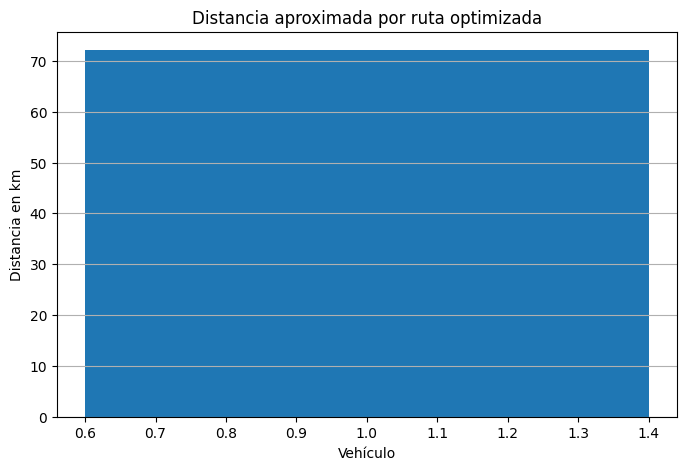

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(resumen_rutas["Vehiculo"], resumen_rutas["Distancia_2opt_km"])
plt.title("Distancia aproximada por ruta optimizada")
plt.xlabel("Vehículo")
plt.ylabel("Distancia en km")
plt.grid(axis="y")
plt.show()

## Mapa final de rutas

El mapa permite revisar visualmente la distribución de las rutas. Cada color representa un vehículo diferente.

In [30]:
colores = [
    "blue", "green", "purple", "orange", "darkred", "cadetblue",
    "darkblue", "darkgreen", "pink", "gray", "black"
]

mapa_rutas = folium.Map(location=deposito, zoom_start=11)

folium.Marker(
    location=deposito,
    popup="Depósito LogiExpress",
    icon=folium.Icon(color="red", icon="home")
).add_to(mapa_rutas)

for i, ruta in enumerate(rutas_base, start=1):
    color_ruta = colores[(i - 1) % len(colores)]
    coordenadas_ruta = []

    for nodo in ruta["ruta_2opt"]:
        punto = puntos[puntos["Nodo"] == nodo].iloc[0]
        coordenadas_ruta.append([punto["Latitud"], punto["Longitud"]])

    folium.PolyLine(
        locations=coordenadas_ruta,
        color=color_ruta,
        weight=4,
        opacity=0.8,
        popup=f"Vehículo {i}"
    ).add_to(mapa_rutas)

    for nodo in ruta["nodos"]:
        punto = puntos[puntos["Nodo"] == nodo].iloc[0]
        folium.CircleMarker(
            location=[punto["Latitud"], punto["Longitud"]],
            radius=5,
            popup=f"Vehículo {i} | {punto['Pedido_ID']} | {punto['Peso_kg']} kg",
            color=color_ruta,
            fill=True,
            fill_opacity=0.7
        ).add_to(mapa_rutas)

mapa_rutas

## Puntos mínimos de análisis para el informe

Cada grupo debe entregar un informe corto o una sección final dentro del notebook con los siguientes elementos:

1. Descripción del dataset utilizado y origen de los datos.
2. Evidencia de carga desde Kaggle o de los archivos originales descargados desde Kaggle.
3. Valor usado en `numero_pedidos_a_cargar`; para la entrega final debe ser mínimo 30.
4. Diccionario mínimo de variables usadas en el problema.
5. Explicación de cómo se construyeron las ubicaciones de entrega a partir de las tablas originales.
6. Evidencia de limpieza y validación de coordenadas.
7. Explicación de la fórmula de Haversine y su utilidad para este caso.
8. Gráfica y discusión del tiempo de ejecución de la fuerza bruta.
9. Explicación del criterio usado para agrupar pedidos por capacidad.
10. Comparación entre vecino más cercano y 2-opt.
11. Discusión de limitaciones: distancia geográfica vs. distancia real por calles, tráfico, horarios, capacidad de flota, entre otros.
12. Conclusión técnica sobre por qué se requieren heurísticas para problemas de optimización con muchos pedidos.

## Actividad autónoma

Para la entrega final cada grupo debe ajustar este notebook de la siguiente forma:

- Ejecutar primero el notebook con pocos registros para verificar que todas las celdas funcionen.
- Cambiar `numero_pedidos_a_cargar` a `30` en la sección de parámetros generales.
- Usar el dataset de Kaggle sugerido o justificar otro dataset de e-commerce, entregas, logística o movilidad.
- Documentar el nombre del dataset, enlace, fuente y criterio de selección.
- Cargar los archivos originales y construir una tabla de mínimo 30 ubicaciones de entrega.
- Validar coordenadas, pesos, registros nulos y duplicados.
- Calcular la matriz de distancias con Haversine.
- Ejecutar el experimento de fuerza bruta solo con subconjuntos pequeños.
- Construir las rutas con capacidad máxima de 100 kg.
- Aplicar vecino más cercano y 2-opt.
- Presentar la tabla resumen de rutas y el mapa final.
- Sustentar oralmente las decisiones del código.

No se evaluará únicamente que el código ejecute. También se evaluará que el grupo entienda qué problema está resolviendo, qué restricciones modeló, cómo preparó los datos y qué limitaciones tiene la solución propuesta.

## Rúbrica sugerida

| Criterio | Descripción | Porcentaje |
|---|---|---:|
| Ingeniería de datos con Kaggle | Búsqueda del dataset, carga de archivos, integración de tablas, limpieza, validación de coordenadas y construcción de las 30 ubicaciones. | 25% |
| Análisis de complejidad | Experimento de fuerza bruta, gráfica de tiempo y explicación de crecimiento combinatorio/factorial. | 25% |
| Implementación algorítmica | Construcción de rutas por capacidad, vecino más cercano, aplicación de 2-opt y resumen comparativo. | 35% |
| Sustentación oral | Claridad técnica, defensa de decisiones y comprensión de limitaciones del modelo. | 15% |

## Preguntas de cierre para sustentación

1. ¿Por qué el dataset original de Kaggle no se podía usar directamente sin preparación?
2. ¿Qué tablas se tuvieron que unir para construir las ubicaciones de entrega?
3. ¿Por qué se usó Haversine y qué limitaciones tiene frente a una distancia real por calles?
4. ¿Por qué no es viable resolver todos los pedidos por fuerza bruta?
5. ¿Qué diferencia hay entre encontrar una solución óptima y encontrar una solución suficientemente buena?
6. ¿Qué pasaría si se agregan ventanas de tiempo o prioridad de clientes?
7. ¿Qué parte del notebook cambiarían si tuvieran que procesar 10.000 pedidos?